# Reionization History Pipeline

This notebook collects verification and diagnostics used during development of the
**Reio_hist** pipeline (CLASS + MUSIC + SCRIPT + Cobaya). It is organised into sections:

1. **P(k) grid resolution & sigma8** - how CLASS `P_k_max` / `k_per_decade_for_pk`
   settings affect the power spectrum and the recovered `sigma8`.
2. **UVLF model checks** - chi2 grid choice and parameter scans (`log10Mcrit`, `asum`).
3. **Cobaya Planck likelihoods** - chi2 breakdown from the joint UVLF+CMB model.
4. **Reionization history -> C_l** - the two parameter modes and their CMB power spectra.


## Path Setup

Run this notebook from the repository root. `PROJECT` is auto-detected from the current
working directory; the data files live in `data_files/`. Do not delete this, unless required.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os, sys
from pathlib import Path

PROJECT = os.getcwd()                  
DATA_DIR = os.path.join(PROJECT, "data_files")

%matplotlib inline



# P(k) grid resolution & sigma8

Check how the CLASS `P_k_max` / `k_per_decade_for_pk` grid settings affect the power
spectrum, the number of returned k-points, and the value of `sigma8` recovered from the
grid used by the model. This motivated the switch to a uniform `logspace` grid with
`P_k_max = 500`, `k_per_decade = 20`.


In [3]:
from classy import Class

for pkmax, kperdec in [(50, None), (100, 10), (500, 20), (1000, 30), (2000, 40)]:
    settings = {"output": "mPk", "z_max_pk": 1., "P_k_max_1/Mpc": pkmax,
                "H0": 67.36, "omega_b": 0.02237, "omega_cdm": 0.12,
                "n_s": 0.9649, "A_s": 2.1e-9}
    if kperdec:
        settings["k_per_decade_for_pk"] = kperdec
    c = Class(); c.set(settings); c.compute()
    print(f"P_k_max={pkmax}, kperdec={kperdec}: CLASS sigma8 = {c.sigma8():}")

    pk, k, z = c.get_pk_and_k_and_z(nonlinear=False)
    h = 0.6736
    kk = k / h
    Pk = pk[:, -1] * h**3
    R = 8.0
    x = kk * R
    W = 3 * (np.sin(x) - x * np.cos(x)) / x**3
    s8 = np.sqrt(np.trapezoid(Pk * W**2 * kk**2, kk) / (2 * np.pi**2))
    print(f"    your sigma8 from lnk/lnpk = {s8:.5f}    (n_k = {len(k)})")
    c.struct_cleanup()


P_k_max=50, kperdec=None: CLASS sigma8 = 0.8229091678795974
    your sigma8 from lnk/lnpk = 0.82289    (n_k = 131)
P_k_max=100, kperdec=10: CLASS sigma8 = 0.8229091679615396
    your sigma8 from lnk/lnpk = 0.82289    (n_k = 134)
P_k_max=500, kperdec=20: CLASS sigma8 = 0.8229100217872903
    your sigma8 from lnk/lnpk = 0.82302    (n_k = 209)
P_k_max=1000, kperdec=30: CLASS sigma8 = 0.8229102331021377
    your sigma8 from lnk/lnpk = 0.82301    (n_k = 287)
P_k_max=2000, kperdec=40: CLASS sigma8 = 0.8229120149380066
    your sigma8 from lnk/lnpk = 0.82300    (n_k = 370)


In [4]:
import massfunction

for pkmax, kpd in [(50, None), (500, 20), (2000, 40)]:
    s = {"output": "mPk", "z_max_pk": 1., "P_k_max_1/Mpc": pkmax,
         "H0": 67.36, "omega_b": 0.02237, "omega_cdm": 0.12,
         "n_s": 0.9649, "A_s": 2.1e-9}
    if kpd:
        s["k_per_decade_for_pk"] = kpd
    c = Class(); c.set(s); c.compute()
    pk, k, z = c.get_pk_and_k_and_z(nonlinear=False)
    h = 0.6736
    lnk = np.log(k / h)
    lnpk = np.log(pk[:, -1] * h**3)
    cdict = {"omega_M_0": 0.314, "omega_b_0": 0.049, "h": h, "YHe": 0.24,
             "omega_L_0": 0.686}
    M, _, _, _, _, _, dndm, _ = massfunction.get_massfunction(
        8.0, 12.0, 0.1, 6.0, lnk, lnpk, cdict, fit="ST", delta_c=1.686)
    print(f"pkmax={pkmax}: dndm[0]={dndm[0]:}, dndm[-1]={dndm[-1]:}")
    c.struct_cleanup()


pkmax=50: dndm[0]=1.429406781252259e-07, dndm[-1]=1.1462108641249844e-15
pkmax=500: dndm[0]=1.636084372686944e-07, dndm[-1]=5.819094645750158e-16
pkmax=2000: dndm[0]=1.7378080715691963e-07, dndm[-1]=1.7872810546467087e-16


# UVLF model checks

Verify the UVLF / QHI model (`reion_uvlf_*`) against the CLASS power spectrum. This
requires `data_files/` to be the working directory (the model reads the UVLF and QHI
data files via relative paths).


In [5]:
os.chdir(DATA_DIR)
sys.path.insert(0, PROJECT)
import reion_uvlf_4params as uvlf
import reion_uvlf_funcs as rf
from classy import Class


c = Class()
c.set({"output": "mPk", "P_k_max_1/Mpc": 500., "z_max_pk": 1.,
                    "k_per_decade_for_pk": 20,
                    "H0": 67.36, "omega_b": 0.02237, "omega_cdm": 0.12,
                    "n_s": 0.9649, "A_s": 2.1e-9})
c.compute()
h = 0.6736
kk = np.logspace(-4, np.log10(500), 2000)
Pk0 = np.array([c.pk_lin(kv, 0.0) for kv in kk])
lnk = np.log(kk / h)
lnpk = np.log(Pk0 * h**3)
c.struct_cleanup()
print("P(k) grid built:", len(kk), "points, k=[", kk.min(), ",", kk.max(), "]")
print("cwd =", os.getcwd())


P(k) grid built: 2000 points, k=[ 0.0001 , 499.99999999999994 ]
cwd = /home/aayush/testing_bench/data_files


### Grid choice: non-uniform vs uniform log-k

The UVLF model expects a uniform log-k grid; using the raw (non-uniform) CLASS grid
produces a very poor chi2.


In [6]:
# current (non-uniform) CLASS grid
pk, k, z = c.get_pk_and_k_and_z(nonlinear=False)
lnk1 = np.log(k / h); lnpk1 = np.log(pk[:, -1] * h**3)
logl1, d1 = uvlf.log_likelihood(-0.458, -0.883, 10.78, 1.148,
                                lnk1, lnpk1, 0.314, 0.686, h, 0.049, YHe=0.24)
print("NON-uniform grid chi2:", -2 * logl1)

# uniform logspace grid
logl2, d2 = uvlf.log_likelihood(-0.458, -0.883, 10.78, 1.148,
                                lnk, lnpk, 0.314, 0.686, h, 0.049, YHe=0.24)
print("UNIFORM grid chi2:", -2 * logl2)


NON-uniform grid chi2: 12235.981660365043
UNIFORM grid chi2: 55.125653478208854


### Split the UVLF and QHI chi2

For the best-fit point (-0.2, -0.75, 13, 2.16), break the total chi2 into its UVLF and
QHI components, and list the model / data / sigma arrays.


In [7]:
c = Class()
c.set({"output": "mPk", "P_k_max_1/Mpc": 500., "z_max_pk": 1., "k_per_decade_for_pk": 20,
       "H0": 67.36, "omega_b": 0.02237, "omega_cdm": 0.12, "n_s": 0.9649, "A_s": 2.1e-9})
c.compute()
pk, k, z = c.get_pk_and_k_and_z(nonlinear=False)
h = 0.6736
Pk0 = pk[:, -1]
lnk = np.log(k / h)
lnpk = np.log(Pk0 * h**3)
c.struct_cleanup()

lsum, ldiff, l2, l3 = -0.2, -0.75, 13, 2.16
omega_m, omega_l, omega_b = 0.31, 0.69, 0.049
cdict = {"omega_M_0": omega_m, "omega_b_0": omega_b, "h": h, "YHe": 0.24,
         "omega_L_0": omega_l}

asum, adiff = 9.4376e-01, 2.8934e-01
log10_fesc10, alpha_esc, log10Mcrit = -8.1220e-01, -7.8249e-02, 1.0174e+01
a2, a3 = l2, l3

# reionization history
z_arr, QHII_arr, tau = rf.reionHist_model(
    lsum, ldiff, l2, l3, asum, adiff, a2, a3,
    log10Mcrit, log10_fesc10, alpha_esc, lnk, lnpk, cdict)

# UVLF chi2
model_QHI_UVLF_arr = []
m_uvlf, d_uvlf, s_uvlf = rf.model_and_data_allUVLF(
    model_QHI_UVLF_arr, log10Mcrit, lsum, ldiff, l2, l3, asum, adiff, a2, a3,
    log10_fesc10, alpha_esc, lnk, lnpk, cdict)
chisq_UVLF = rf.get_chisq(m_uvlf, d_uvlf, s_uvlf)

# QHI chi2
m_qhi, d_qhi, s_qhi = rf.model_and_data_QHI(z_arr, QHII_arr)
chisq_QHI = rf.get_chisq(m_qhi, d_qhi, s_qhi)

print("chisq_UVLF:", chisq_UVLF)
print("chisq_QHI: ", chisq_QHI)
print("total:     ", chisq_UVLF + chisq_QHI)
print("tau:       ", tau)
print()
print("UVLF model values:", np.array(m_uvlf)[:5])
print("UVLF data values: ", np.array(d_uvlf)[:5])
print("UVLF sigma values:", np.array(s_uvlf)[:5])


chisq_UVLF: 14642.998038381545
chisq_QHI:  62.68522970742122
total:      14705.683268088967
tau:        0.07049446455835169

UVLF model values: [0.02077886 0.01334828 0.00755823 0.00458725 0.00320805]
UVLF data values:  [0.02512  0.00878  0.00462  0.002159 0.001594]
UVLF sigma values: [0.00734  0.00154  0.00052  0.000346 0.000156]


### Parameter scans

Scan `log10Mcrit` and the `asum` normalization to see how the UVLF chi2 responds.


In [8]:
# scan log10Mcrit
for Mcrit in [9.5, 10.0, 10.174, 10.5, 11.0]:
    m, d, s = rf.model_and_data_allUVLF(
        [], Mcrit, lsum, ldiff, l2, l3, asum, adiff, l2, l3,
        log10_fesc10, alpha_esc, lnk, lnpk, cdict)
    print(f"Mcrit={Mcrit}: chisq_UVLF={rf.get_chisq(m, d, s):}")


Mcrit=9.5: chisq_UVLF=17257.653363479643
Mcrit=10.0: chisq_UVLF=15551.029903432122
Mcrit=10.174: chisq_UVLF=14642.998038381545
Mcrit=10.5: chisq_UVLF=12557.761175349944
Mcrit=11.0: chisq_UVLF=9232.103311096404


In [10]:
# scan the alpha_star normalization (asum controls a0 = (asum+adiff)/2)
for asum_test in [0.5, 0.7, 0.944, 1.2, 1.5]:
    m, d, s = rf.model_and_data_allUVLF(
        [], 10.174, lsum, ldiff, l2, l3, asum_test, adiff, l2, l3,
        log10_fesc10, alpha_esc, lnk, lnpk, cdict)
    print(f"asum={asum_test}: chisq_UVLF={rf.get_chisq(m, d, s):}")


asum=0.5: chisq_UVLF=13581.690522785797
asum=0.7: chisq_UVLF=14067.409195280086
asum=0.944: chisq_UVLF=14643.558982232224
asum=1.2: chisq_UVLF=15237.154024915855
asum=1.5: chisq_UVLF=15920.65080301822


# Cobaya Planck likelihoods

Evaluate the joint UVLF + CMB model (`mcmc_uvlf_cmb`) for several parameter points and
report the per-likelihood chi2 breakdown and the derived `tau_e`.


In [2]:
os.chdir(PROJECT)
from cobaya.model import get_model
import mcmc_uvlf_cmb as M

model = get_model(M.info)

# the two modes (galaxy params)
modes = {
    "mode 1 (UVLF-only best-fit, tau~0.054)": {
        "lsum": -0.458, "ldiff": -0.883, "l2": 10.78, "l3": 1.148},
    "mode 2 (joint 'best-fit' found, tau~0.0595)": {
        "lsum": 2.0068, "ldiff": -0.9335, "l2": 16.42, "l3": 4.510},
}

print(f"{'mode':52s} {'tau_e':>8s} {'chi2_uvlf':>10s} {'chi2_CMB':>10s} {'chi2_tot':>10s}")
print("-" * 95)

for label, gal in modes.items():
    loglikes, derived = model.loglikes(dict(gal, n_s=0.965, logA=3.043), as_dict=True, return_derived=True)
    chi2_uvlf = -2 * loglikes["uvlf"]
    chi2_cmb = (-2 * loglikes["planck_2018_lowl.TT"]
                - 2 * loglikes["planck_2018_lowl.EE"]
                - 2 * loglikes["planck_2018_highl_plik.TTTEEE_lite"])
    tau = derived.get("tau_e", float("nan"))
    print(f"{label:52s} {tau:8.5f} {chi2_uvlf:10.2f} {chi2_cmb:10.2f} {chi2_uvlf+chi2_cmb:10.2f}")

print("-" * 95)
print("\nPer-CMB-likelihood breakdown:")
for label, gal in modes.items():
    loglikes, derived = model.loglikes(dict(gal, n_s=0.965, logA=3.043), as_dict=True, return_derived=True)
    print(f"\n{label}  (tau={derived.get('tau_e'):.5f}):")
    for name in ["planck_2018_lowl.TT", "planck_2018_lowl.EE",
                 "planck_2018_highl_plik.TTTEEE_lite"]:
        print(f"    {name:38s} chi2 = {-2 * loglikes[name]:10.3f}")


[model] *WARNING* Ignored blocks/options: ['sampler', 'output', 'resume']
[classy_reio] `classy` module loaded successfully from /home/aayush/.local/lib/python3.14/site-packages
[planck_2018_highl_plik.ttteee_lite] `clipy` module loaded successfully from /home/aayush/testing_bench/cobaya_packages/code/planck/clipy/clipy
----
clipy_0.15
Checking likelihood '/home/aayush/testing_bench/cobaya_packages/data/planck_2018/baseline/plc_3.0/hi_l/plik_lite/plik_lite_v22_TTTEEE.clik' on test data. got -292.286 expected -292.286 (diff -3.86314e-09)
----
before crop : TT 30 -> 2508, TE 30 -> 1996, EE 30 -> 1996
after crop  : TT 30 -> 2508, TE 30 -> 1996, EE 30 -> 1996
mode                                                    tau_e  chi2_uvlf   chi2_CMB   chi2_tot
-----------------------------------------------------------------------------------------------
mode 1 (UVLF-only best-fit, tau~0.054)                0.05387      55.58    1115.72    1171.30
mode 2 (joint 'best-fit' found, tau~0.0595)       

# Reionization history -> C_l

Compare the two parameter modes through their UVLF model reionization histories, their
CLASS-derived `tau_reio`, and the resulting CMB power spectra (plus fractional
differences).


In [3]:
os.chdir(DATA_DIR)
sys.path.insert(0, PROJECT)
import reion_uvlf_4params as uvlf
from classy import Class

# fixed cosmology
COSMO = {"H0": 67.4, "omega_b": 0.0224, "omega_cdm": 0.120,
         "n_s": 0.965, "A_s": 2.097e-9}
h = 0.674
HE, HE_LOW = 1.0789, 1.1578
LMAX = 2500

# ---- P(k) (uniform log grid) ----
c = Class(); c.set({"output": "mPk", "P_k_max_1/Mpc": 500., "z_max_pk": 1.,
                    "k_per_decade_for_pk": 20, **COSMO}); c.compute()
kk = np.logspace(-4, np.log10(500), 2000)
Pk0 = np.array([c.pk_lin(kv, 0.0) for kv in kk])
lnk, lnpk = np.log(kk / h), np.log(Pk0 * h**3)
om = (0.120 + 0.0224) / h**2
ob = 0.0224 / h**2
ol = 1 - om
c.struct_cleanup()

MODES = {
    "mode 1 (UVLF best-fit)": dict(p=(-0.458, -0.883, 10.78, 1.148), color="tab:blue"),
    "mode 2 (CMB-preferred)": dict(p=(2.0068, -0.9335, 16.42, 4.510), color="tab:red"),
}

def history_and_cls(params):
    lsum, ldiff, l2, l3 = params
    logl, d = uvlf.log_likelihood(lsum, ldiff, l2, l3, lnk, lnpk,
                                  om, ol, h, ob, YHe=0.24)
    z = np.asarray(d["z_arr"]); Q = np.asarray(d["QHII_arr"])
    o = np.argsort(z); z, Q = z[o], Q[o]
    xe = np.where(z >= 3.0, Q * HE, Q * HE_LOW)
    xe = np.where(xe < 1e-4, 0.0, xe)
    nz = np.where(xe > 0)[0]; last = int(nz[-1])
    z2 = np.append(z[:last + 1], z[last + 1] if last + 1 < len(z) else z[-1] + 0.2)
    x2 = np.append(xe[:last + 1], 0.0)
    cc = Class(); cc.set({"output": "tCl,pCl,lCl", "lensing": "yes", "N_ur": 3.044,
                          **COSMO,
                          "reio_parametrization": "reio_inter",
                          "reio_inter_num": int(len(z2)),
                          "reio_inter_z": ",".join(f"{v:g}" for v in z2),
                          "reio_inter_xe": ",".join(f"{v:.6f}" for v in x2)})
    cc.compute()
    cls = cc.lensed_cl(LMAX)
    tau = cc.get_current_derived_parameters(['tau_reio'])['tau_reio']
    cc.struct_cleanup()
    return z, Q, cls, tau, -2 * logl

results = {}
for name, cfg in MODES.items():
    z, Q, cls, tau, chi2u = history_and_cls(cfg["p"])
    results[name] = dict(z=z, Q=Q, cls=cls, tau=tau, chi2u=chi2u, color=cfg["color"])
    print(f"{name}: tau={tau:.5f}  chi2_uvlf={chi2u:.1f}")


mode 1 (UVLF best-fit): tau=0.05332  chi2_uvlf=55.6
mode 2 (CMB-preferred): tau=0.05885  chi2_uvlf=83.2


### Power spectra + fractional differences


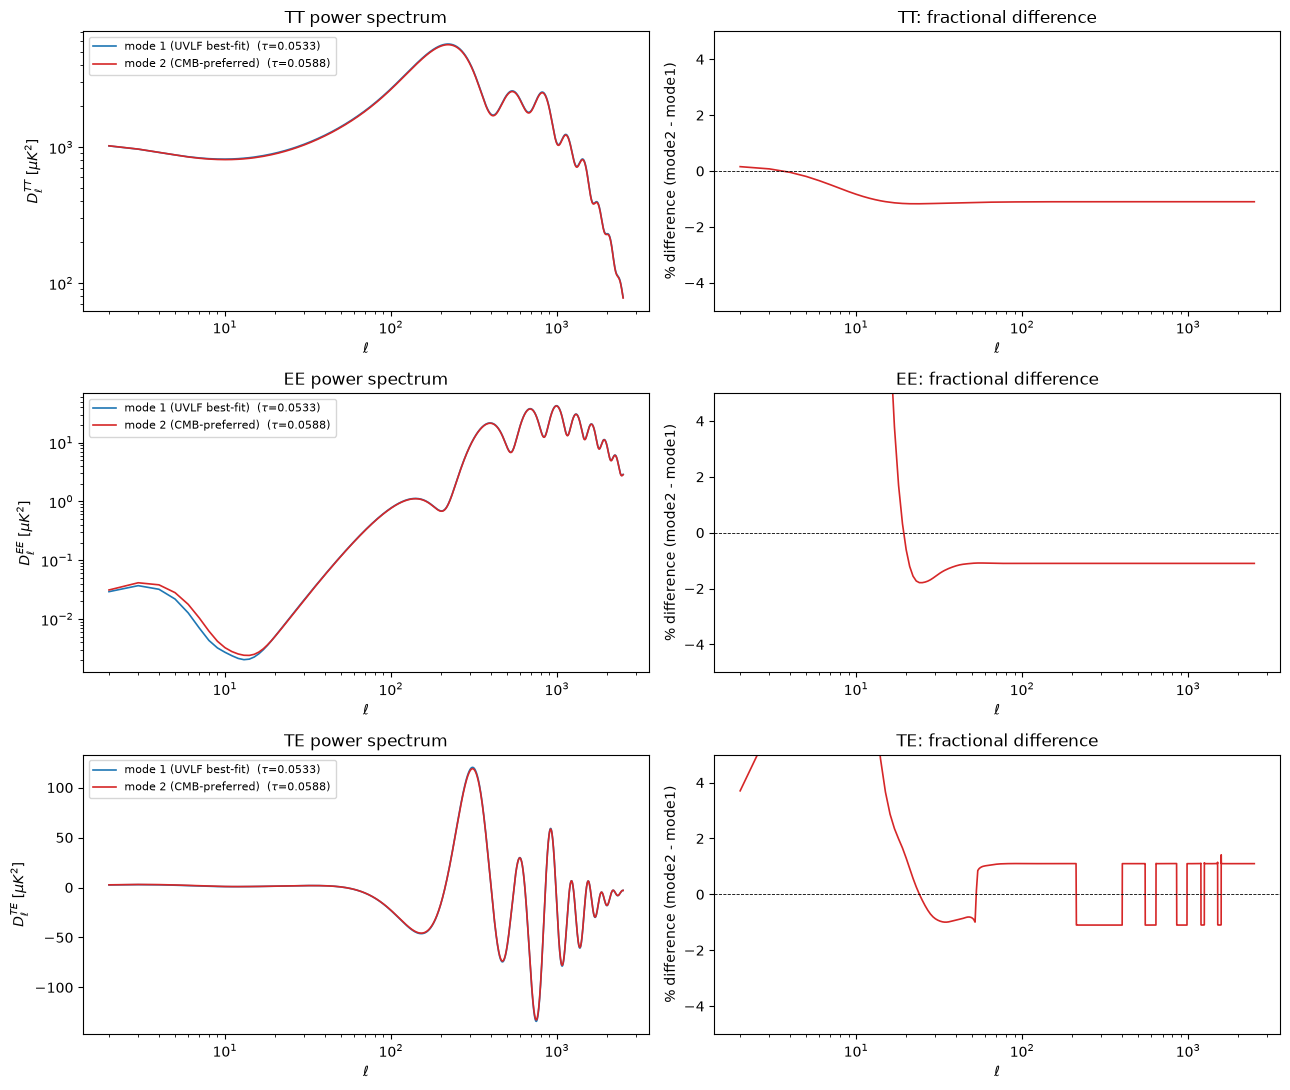

In [4]:
ell = np.arange(LMAX + 1)
fac = ell * (ell + 1) / (2 * np.pi) * (2.7255e6)**2      # -> D_l in muK^2
ref = list(results.values())[0]                           # mode 1 as reference

fig, axes = plt.subplots(3, 2, figsize=(13, 11),
                         gridspec_kw={"height_ratios": [2, 2, 2]})
spectra = [("tt", "TT"), ("ee", "EE"), ("te", "TE")]

for row, (key, lbl) in enumerate(spectra):
    ax, axd = axes[row, 0], axes[row, 1]
    for name, r in results.items():
        D = fac * r["cls"][key]
        ax.plot(ell[2:], D[2:], color=r["color"], lw=1.2,
                label=f"{name}  ($\\tau$={r['tau']:.4f})")
    ax.set_xscale("log"); ax.set_ylabel(f"$D_\\ell^{{{lbl}}}$ [$\\mu K^2$]")
    ax.set_xlabel(r"$\ell$"); ax.legend(fontsize=8)
    if key != "te":
        ax.set_yscale("log")
    ax.set_title(f"{lbl} power spectrum")

    # fractional difference (mode2 - mode1)/mode1
    for name, r in results.items():
        if r is ref:
            continue
        num = r["cls"][key][2:]; den = ref["cls"][key][2:]
        with np.errstate(divide="ignore", invalid="ignore"):
            frac = np.where(den != 0, (num - den) / np.abs(den), np.nan)
        axd.plot(ell[2:], 100 * frac, color=r["color"], lw=1.2)
    axd.axhline(0, color="k", lw=0.6, ls="--")
    axd.set_xscale("log"); axd.set_xlabel(r"$\ell$")
    axd.set_ylabel("% difference (mode2 - mode1)")
    axd.set_title(f"{lbl}: fractional difference")
    axd.set_ylim(-5, 5)

plt.tight_layout()
plt.show()


### Reionization histories


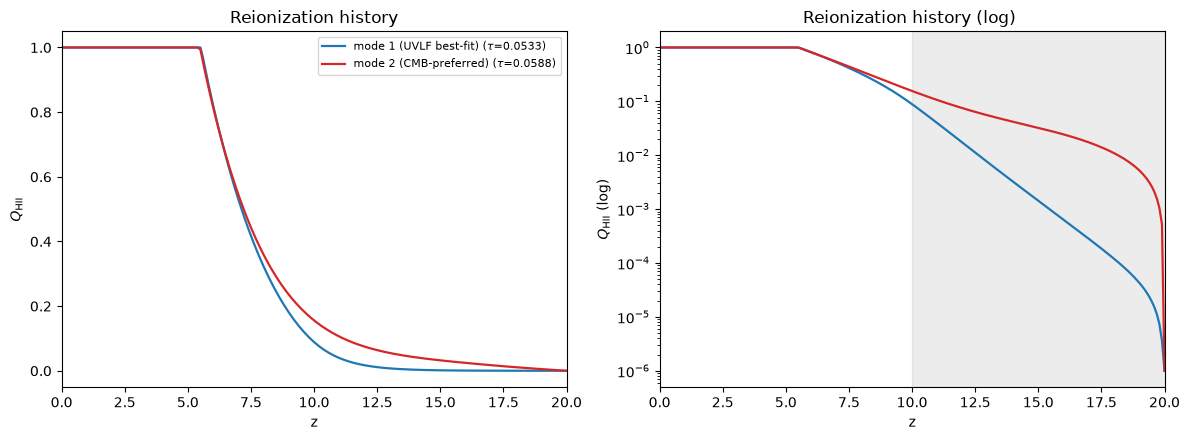

In [6]:
fig2, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.5))
for name, r in results.items():
    a1.plot(r["z"], r["Q"], color=r["color"], lw=1.6,
            label=f"{name} ($\\tau$={r['tau']:.4f})")
    a2.semilogy(r["z"], np.maximum(r["Q"], 1e-6), color=r["color"], lw=1.6)
a1.set_xlabel("z"); a1.set_ylabel(r"$Q_{\rm HII}$"); a1.set_xlim(0, 20)
a1.legend(fontsize=8); a1.set_title("Reionization history")
a2.set_xlabel("z"); a2.set_ylabel(r"$Q_{\rm HII}$ (log)"); a2.set_xlim(0, 20)
a2.set_title("Reionization history (log) ")
a2.axvspan(10, 20, color="gray", alpha=0.15)
plt.tight_layout()
plt.show()


# In the previous cells, "asum","adiff","log10_fesc10","alpha_esc","log10Mcrit" are fixed. In the later cell it can be changed.

# Evaluate the UVLF + CMB likelihood for ONE set of 9 parameters

This notebook evaluates exactly what `mcmc_uvlf_9params.py` computes for a single point:
the CLASS P(k), the UVLF/QHI model, the reionization history fed into CLASS, the Planck
2018 lowl TT/EE and highl TTTEEE lite likelihoods, and the derived `tau_e`.

**To use:** edit the parameter values in the `POINT` cell below, then run all cells.

**Fixed in the run** (not free, same as the MCMC): `H0 = 67.4`, `omega_b = 0.0224`,
`omega_cdm = 0.120`. The free params are the 9 astrophysics ones, plus `n_s`,`logA`.

In [1]:
import os, sys, copy
import numpy as np
#project directory auto-detected from cwd (run notebook from repo root)
PROJECT = os.getcwd()          
DATA_DIR = os.path.join(PROJECT, "data_files")
sys.path.insert(0, PROJECT)
os.chdir(DATA_DIR)  
print("cwd:", os.getcwd())

cwd: /home/aayush/testing_bench/data_files


In [2]:
import mcmc_uvlf_9params as mcmcmod
from cobaya.model import get_model

info = copy.deepcopy(mcmcmod.info)
info.pop("output", None)
info.pop("resume", None)
info.pop("sampler", None)   # no MCMC here

model = get_model(info)
derived_names = list(model.parameterization.derived_params().keys())
print("derived params:", derived_names)
print("likelihoods:", list(model.likelihood.keys()))
print("model ready.")

[classy_reio] `classy` module loaded successfully from /home/aayush/.local/lib/python3.14/site-packages
[planck_2018_highl_plik.ttteee_lite] `clipy` module loaded successfully from /home/aayush/testing_bench/cobaya_packages/code/planck/clipy/clipy
----
clipy_0.15
Checking likelihood '/home/aayush/testing_bench/cobaya_packages/data/planck_2018/baseline/plc_3.0/hi_l/plik_lite/plik_lite_v22_TTTEEE.clik' on test data. got -292.286 expected -292.286 (diff -3.86314e-09)
----
before crop : TT 30 -> 2508, TE 30 -> 1996, EE 30 -> 1996
after crop  : TT 30 -> 2508, TE 30 -> 1996, EE 30 -> 1996
derived params: ['A_s', 'tau_e', 'chi2__CMB']
likelihoods: ['uvlf', 'planck_2018_lowl.TT', 'planck_2018_lowl.EE', 'planck_2018_highl_plik.TTTEEE_lite']
model ready.


## Set the parameter point

Edit the values below. `lsum, ldiff, l2, l3` describe the redshift evolution of
`log10 f_star,10/c_star`; `asum, adiff, log10_fesc10, alpha_esc, log10Mcrit` the other
astrophysics; `n_s`, `logA` the cosmology (priors as in the MCMC).

In [7]:
POINT = {
    # astro params
    "lsum": -0.902196,
    "ldiff": -1.20594,
    "l2": 10.3442,
    "l3": 0.677975,
    "asum": 0.512237,
    "adiff": 0.342735,
    "log10_fesc10": -0.834616,
    "alpha_esc": -0.338567,
    "log10Mcrit": 9.19371,
    # cosmo params
    "n_s": 0.943396,
    "logA": 3.32225,
    # H0 / omega_b / omega_cdm are FIXED in the run (67.4 / 0.0224 / 0.120)
}

In [9]:
res = model.logposterior(POINT, return_derived=True)
dvals = res.derived if isinstance(res.derived, dict) else dict(zip(derived_names, res.derived))

# per-likelihood logL -> chi2 (order follows model.likelihood.keys())
lik_names = list(model.likelihood.keys())
loglikes = {n: float(v) for n, v in zip(lik_names, res.loglikes)}
chi = {n: -2.0 * v for n, v in loglikes.items()}

print("=" * 62)
print(f"log-prior      = {res.logprior:+.4f}")
print(f"log-likelihood = {res.loglike:+.4f}")
print(f"log-posterior  = {res.logpost:+.4f}")
print("-" * 62)
print(f"{'component':<34}{'logL':>10}{'chi2':>12}")
for n in loglikes:
    print(f"{n:<34}{loglikes[n]:+.4f}{chi[n]:12.3f}")
print("-" * 62)
print(f"{'UVLF':<30}{'':<10}{chi['uvlf']:12.3f}")
cmb = sum(v for k, v in chi.items() if k.startswith('planck'))
print(f"{'Total':<30}{'':<10}{cmb:12.3f}")
print("=" * 62)
print(f"tau_e  = {dvals['tau_e']:.6f}")
print(f"A_s    = {dvals['A_s']:.6e}")
if 'chi2__CMB' in dvals:
    print(f"chi2__CMB = {dvals['chi2__CMB']:.3f}")


log-prior      = -11.2569
log-likelihood = -557.4360
log-posterior  = -568.6929
--------------------------------------------------------------
component                               logL        chi2
uvlf                              -25.4383      50.877
planck_2018_lowl.TT               -11.2272      22.454
planck_2018_lowl.EE               -198.5019     397.004
planck_2018_highl_plik.TTTEEE_lite-322.2686     644.537
--------------------------------------------------------------
UVLF                                          50.877
Total                                       1063.995
tau_e  = 0.059308
A_s    = 2.772266e-09
chi2__CMB = 1063.995


### Reionization history that was sent to CLASS (`x_e` vs `z`)

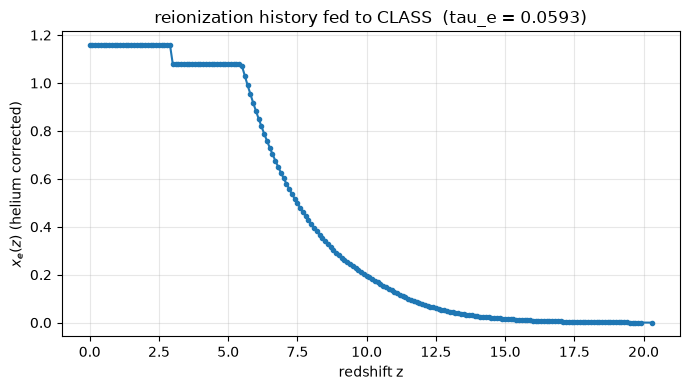

In [ ]:
import matplotlib.pyplot as plt

st = model.theory["uvlf_reio"].current_state
z = np.array([float(v) for v in st["reio_inter_z"].split(",")])
xe = np.array([float(v) for v in st["reio_inter_xe"].split(",")])

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(z, xe, "-o", ms=3)
ax.set_xlabel("redshift z")
ax.set_ylabel(r"$x_e(z)$")
ax.set_title(f"reionization history fed to CLASS  (tau_e = {dvals['tau_e']:.4f})")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### QHI(z) curve and UVLF vs QHI chi^2

Rebuilds the P(k) once (same CLASS settings as the MCMC) and evaluates the model
directly, to check the reionization curve and how the astro chi^2 splits into the
UVLF and QHI parts.

chi2_UVLF =   159.912
chi2_QHI  =    11.624
total     =   171.536   (matches astro chi2 above: 171.536)


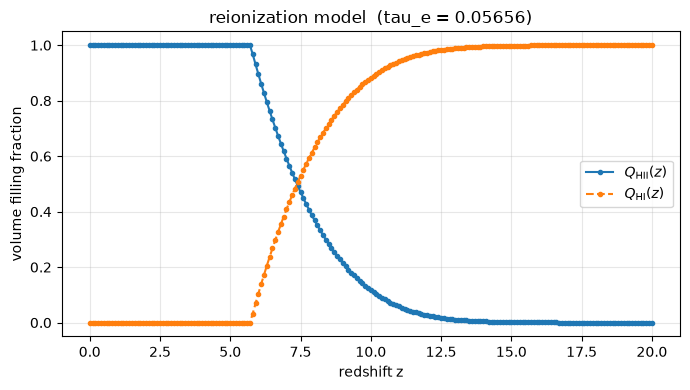

In [6]:
from classy import Class
import reion_uvlf_9params as uvlf
from reion_uvlf_funcs import model_and_data_allUVLF, model_and_data_QHI, get_chisq

# same P(k) build as mcmc_uvlf_9params.UVLFReio.calculate
H0, wb, wc = 67.4, 0.0224, 0.120
h = H0 / 100.0
om = (wc + wb) / h**2
ol = 1.0 - om
ob = wb / h**2
pk = Class()
pk.set({"output": "mPk", "P_k_max_1/Mpc": 100.0, "z_max_pk": 1.0,
        "k_per_decade_for_pk": 20, "H0": H0, "omega_b": wb,
        "omega_cdm": wc, "n_s": POINT["n_s"],
        "A_s": 1e-10 * np.exp(POINT["logA"])})
pk.compute()
kk = np.logspace(-4, np.log10(100), 500)
Pk0 = np.array([pk.pk_lin(k, 0.0) for k in kk])
pk.struct_cleanup()
lnk = np.log(kk / h)
lnpk = np.log(Pk0 * h**3)

logl, dmod = uvlf.log_likelihood(
    POINT["lsum"], POINT["ldiff"], POINT["l2"], POINT["l3"],
    POINT["asum"], POINT["adiff"], POINT["log10_fesc10"],
    POINT["alpha_esc"], POINT["log10Mcrit"],
    lnk, lnpk, om, ol, h, ob, YHe=0.24)

cdict = {"omega_M_0": om, "omega_b_0": ob, "h": h,
         "YHe": 0.24, "omega_L_0": ol}
model_q, data_q, sig_q = model_and_data_allUVLF(
    [], POINT["log10Mcrit"], POINT["lsum"], POINT["ldiff"],
    POINT["l2"], POINT["l3"], POINT["asum"], POINT["adiff"],
    POINT["l2"], POINT["l3"], POINT["log10_fesc10"],
    POINT["alpha_esc"], lnk, lnpk, cdict)
chi_uvlf = get_chisq(model_q, data_q, sig_q)
model_r, data_r, sig_r = model_and_data_QHI(dmod["z_arr"], dmod["QHII_arr"])
chi_qhi = get_chisq(model_r, data_r, sig_r)

print(f"chi2_UVLF = {chi_uvlf:9.3f}")
print(f"chi2_QHI  = {chi_qhi:9.3f}")
print(f"total     = {chi_uvlf + chi_qhi:9.3f}   (matches astro chi2 above: {-2*logl:.3f})")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(dmod["z_arr"], dmod["QHII_arr"], "-o", ms=3, label=r"$Q_{\rm HII}(z)$")
ax.plot(dmod["z_arr"], 1 - dmod["QHII_arr"], "--o", ms=3, label=r"$Q_{\rm HI}(z)$")
ax.set_xlabel("redshift z")
ax.set_ylabel("volume filling fraction")
ax.set_title(f"reionization model  (tau_e = {dmod['tau_e']:.5f})")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()